In this page, you will learn how to:

- subclass `Waveform` to define a custom pulse shape,
- pass and access extra parameters through the base class,
- override the `function` method to implement the waveform evaluation,
- optionally override `max` and `min` for analytical bounds,
- compose custom waveforms with built-in ones,
- use a custom waveform as part of a `Drive`.

In the [waveforms page](../fundamentals/quantum_program.ipynb#waveforms) you saw the usage of the pre-defined waveforms available in QoolQit. The waveform system is designed to be easily extended by subclassing the `Waveform` class and defining a small number of key properties and methods.

## Subclassing Waveform

To exemplify this we will create a waveform representing a simple shifted sine function,

$$
    	Sin(t)_{\omega, C} \equiv \sin(\omega t) + C
$$

In [10]:
import math

from qoolqit.waveforms import Waveform


class Sin(Waveform):
    """A simple sine over a given duration.

    Arguments:
        duration: the total duration.
        omega: the frequency of the sine wave.
        shift: the vertical shift of the sine wave.
    """

    def __init__(
        self,
        duration: float,
        omega: float = 2.0 * math.pi,
        shift: float = 0.0,
    ) -> None:
        super().__init__(duration, omega = omega, shift = shift)

    def function(self, t: float) -> float:
        return math.sin(self.omega * t) + self.shift


A few things are crucial in the snippet above:

- Keeping the `duration` argument as the first one in the `__init__`, and initializing the parent class with that value, to be consistent with other waveforms.
- Passing every other parameter needed for the waveform in the `__init__` and passing it as a **keyword argument** to the parent class. This will automatically create a `params` dictionary of extra parameters, and set them as attributes to be used later.
- Overriding the `function` abstract method, which represents the evaluation of the waveform at some time `t`.
- **Optional**: overriding the `max` and `min` methods. The intended result of `wf.max()` and `wf.min()` is to get the maximum/minimum value the waveform takes over its duration. By default, the base `Waveform` class implements a brute-force sampling method that **approximates** the maximum and minimum values. However, if this value is easy to know from the waveform parameters, the method should be overridden.
- Internally, before being executed by an emulator or a QPU, custom defined waveforms will be converted to an `Interpolated` waveform with a maximum of 100 points. If you need a finer time resolution, please, consider using directly an `Interpolated` waveform.


## Smooth pulse

A profile shaped by $f(t) = \Omega_\text{max} \cdot \sin^2\!\left(\tfrac{\pi}{2} \sin\!\left(\tfrac{\pi\, t}{T}\right)\right)$
starts and ends at zero and reaches $\Omega_\text{max}$ at $t = T/2$, with smooth derivatives
everywhere:

0.00 ≤ t ≤ 6.28: SmoothPulse(t, 1.00)


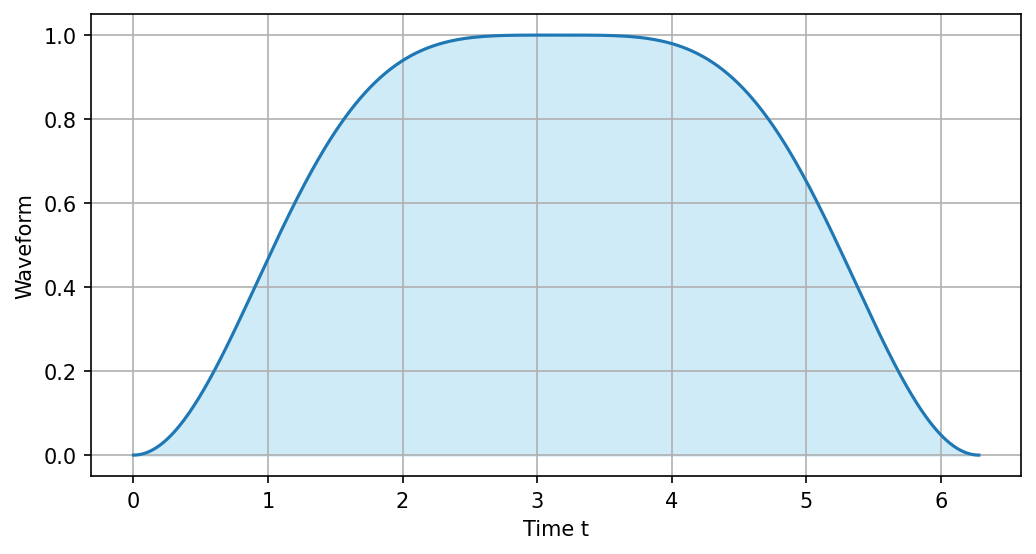

In [11]:
import math

from qoolqit.waveforms import Waveform


class SmoothPulse(Waveform):
    """Smooth bell-shaped pulse: Ω_max · sin²((π/2)·sin(πt/T))."""

    def __init__(self, duration: float, omega_max: float) -> None:
        super().__init__(duration, omega_max=omega_max)

    def function(self, t: float) -> float:
        return self.omega_max * math.sin(0.5 * math.pi * math.sin(math.pi * t / self.duration)) ** 2

    def max(self) -> float:
        # analytic maximum is always omega_max
        return self.omega_max          

    def min(self) -> float:
        # starts and ends at zero
        return 0.0                     

pulse = SmoothPulse(2 * math.pi, omega_max=1.0)
print(pulse)
pulse.draw()

## Using a custom waveform in a Drive
Custom waveforms can be used just like any other waveform in the `Drive` instantiation. For example,

Amplitude: 
0.00 ≤ t ≤ 6.28: SmoothPulse(t, 1.00)

Detuning: 
0.00 ≤ t ≤ 6.28: Ramp(t, -1.00, 1.00)


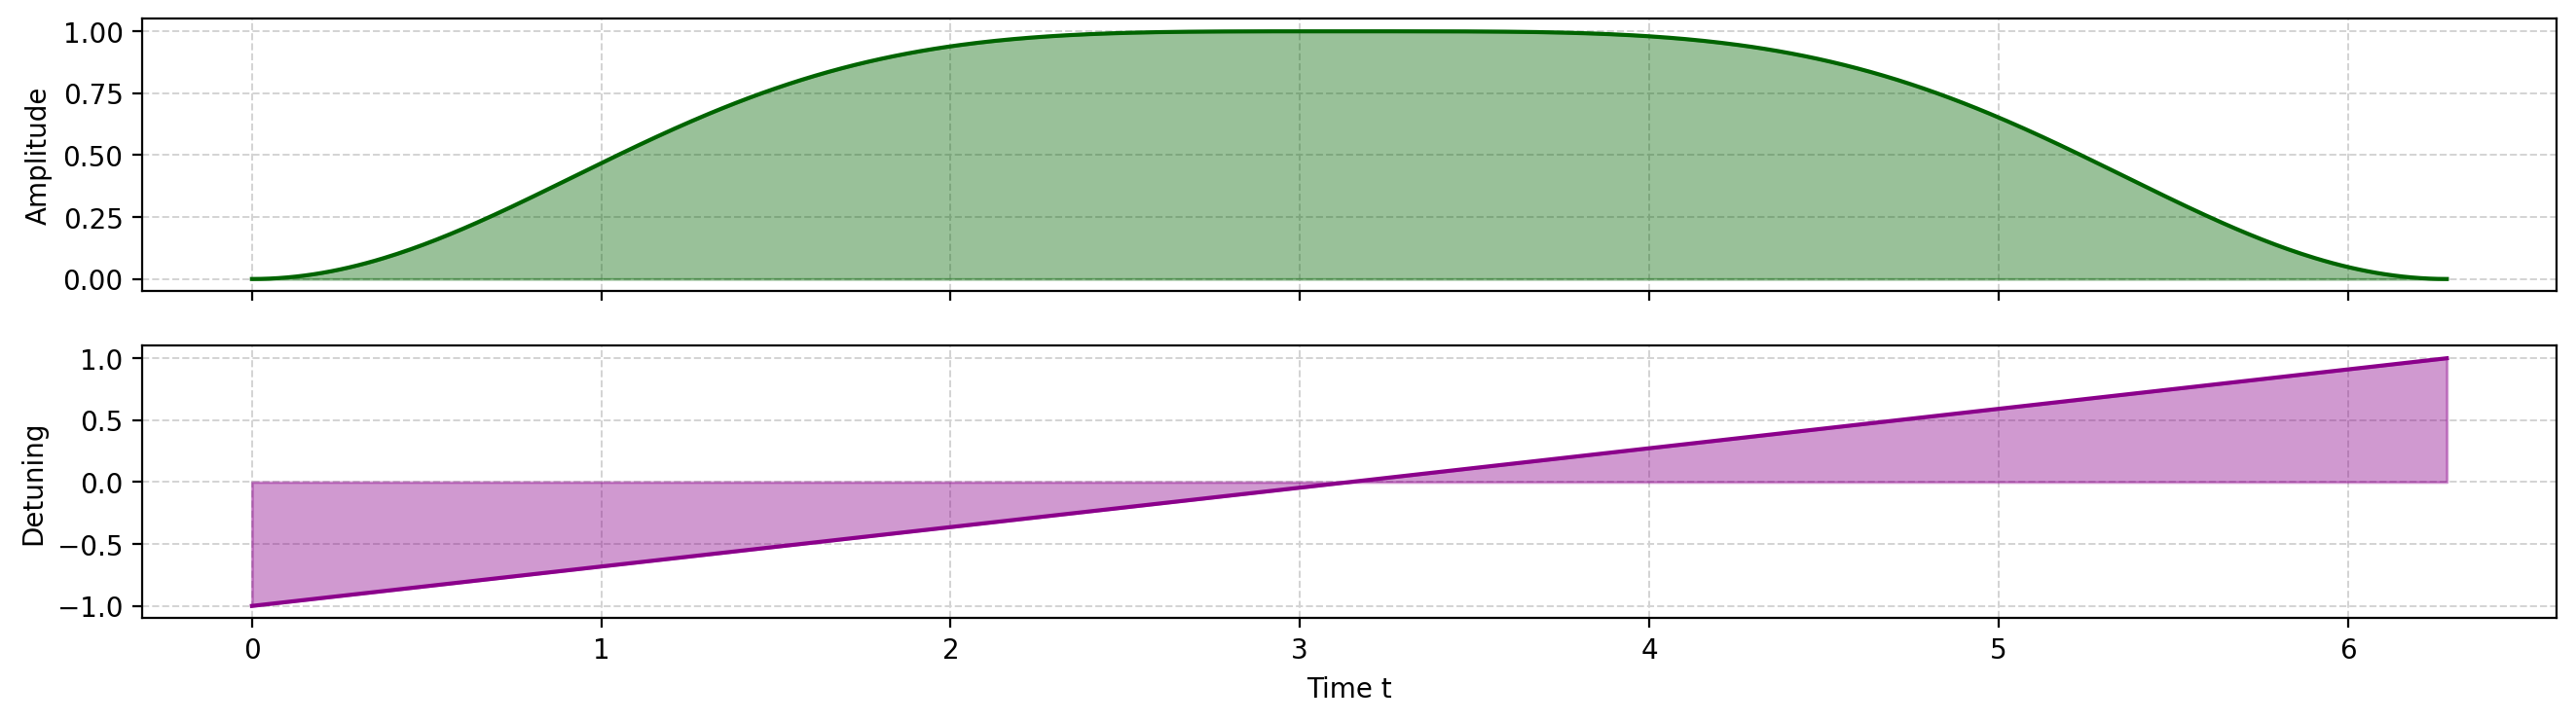

In [ ]:
from qoolqit import Drive, RampWaveform

T = 2 * math.pi
amplitude = SmoothPulse(T, omega_max=1.0)
detuning  = RampWaveform(T, -1.0, 1.0)

drive = Drive(amplitude=amplitude, detuning=detuning)
print(drive)
drive.draw()